# 05 — Fog-severity estimator

Severity is measured with the dark channel prior (He, Sun & Tang, 2009), the standard
training-free, physics-based haze estimator. It is chosen because (i) it derives from
the atmospheric scattering model I = J·t + A·(1 − t) rather than from learned
statistics, so it needs no training data and carries interpretable physical meaning;
(ii) its direction as a fog-density measure is externally validated — a dark-channel
fog-density index matches labelled Cityscapes fog levels with accuracy ≈ 0.98
(Guo, Wang & Li, 2022); and (iii) its behaviour and known limitations are
well documented in the literature (review: Lee et al., 2016).

The computation, per image at native resolution:
1. Dark channel — per-pixel minimum over B, G, R, then a local minimum over a
   15×15 patch (He et al., 2009, Eq. 5).
2. Airlight A — the fog's own light colour: the mean colour of the top 0.1%
   brightest dark-channel pixels (a robust variant of the original selection rule;
   variants reviewed in Lee et al., 2016).
3. Transmission t = 1 − ω·dark(I / A), ω = 0.95 (He et al., 2009, Eq. 12) — the
   per-pixel fraction of scene light surviving the fog.
4. Severity = mean(1 − t) — the average veil fraction of the image, in [0, ω].
   0 means no estimated haze; the score rises with fog density.

No t₀ floor is applied: the floor stabilises image restoration, whereas this
function measures. Known theoretical limitation, examined in later notebooks: the
transmission estimate carries a scene-content-dependent offset (Lee et al., 2016,
Eq. 16) — scenes retaining genuinely dark content through fog are under-scored.

In [1]:
# Setup: mount Drive, set paths, load the estimator from the repo, verify it.
import os
import sys
import importlib
from google.colab import drive

drive.mount('/content/drive')

RAW_RTTS_DIR = "/content/drive/MyDrive/adaptive_perception_data/raw/RTTS"
OUTPUT_ROOT = "/content/drive/MyDrive/perception-difficulty-dve/results"
TABLES_DIR = os.path.join(OUTPUT_ROOT, "tables")
FIGURES_DIR = os.path.join(OUTPUT_ROOT, "figures")

REPO_ROOT = "/content/perception-difficulty-dve"
REPO_URL = "https://github.com/aaaraafaat/perception-difficulty-dve.git"
if not os.path.isdir(REPO_ROOT):
    os.system(f"git clone {REPO_URL} {REPO_ROOT}")
os.system(f"cd {REPO_ROOT} && git pull")
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

import src.features as feat
importlib.reload(feat)

required = ["dark_channel_map", "airlight_estimate", "transmission_map", "dcp_severity_score"]
missing = [name for name in required if not hasattr(feat, name)]
if missing:
    raise ImportError(f"features.py is missing {missing}")
print("Estimator loaded:", ", ".join(required))

Mounted at /content/drive
Estimator loaded: dark_channel_map, airlight_estimate, transmission_map, dcp_severity_score


In [3]:
# Copy RTTS to local disk for fast reading; outputs always save to Drive.
os.makedirs("/content/data", exist_ok=True)
!rsync -a --info=progress2 "{RAW_RTTS_DIR}/" "/content/data/RTTS/"
IMAGES_DIR = "/content/data/RTTS"
print("Reading images from:", IMAGES_DIR)

  1,076,706,036 100%  430.15kB/s    0:40:44 (xfr#8646, to-chk=0/8651)
Reading images from: /content/data/RTTS


## The computation, seen

Three images spanning the severity range, each shown as: original → dark channel →
transmission map → severity. In the transmission map, bright = scene light getting
through (clear), dark = veil. Severity is the average of (1 − transmission).

Saved: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_13_severity_explainer_RTTS.jpg


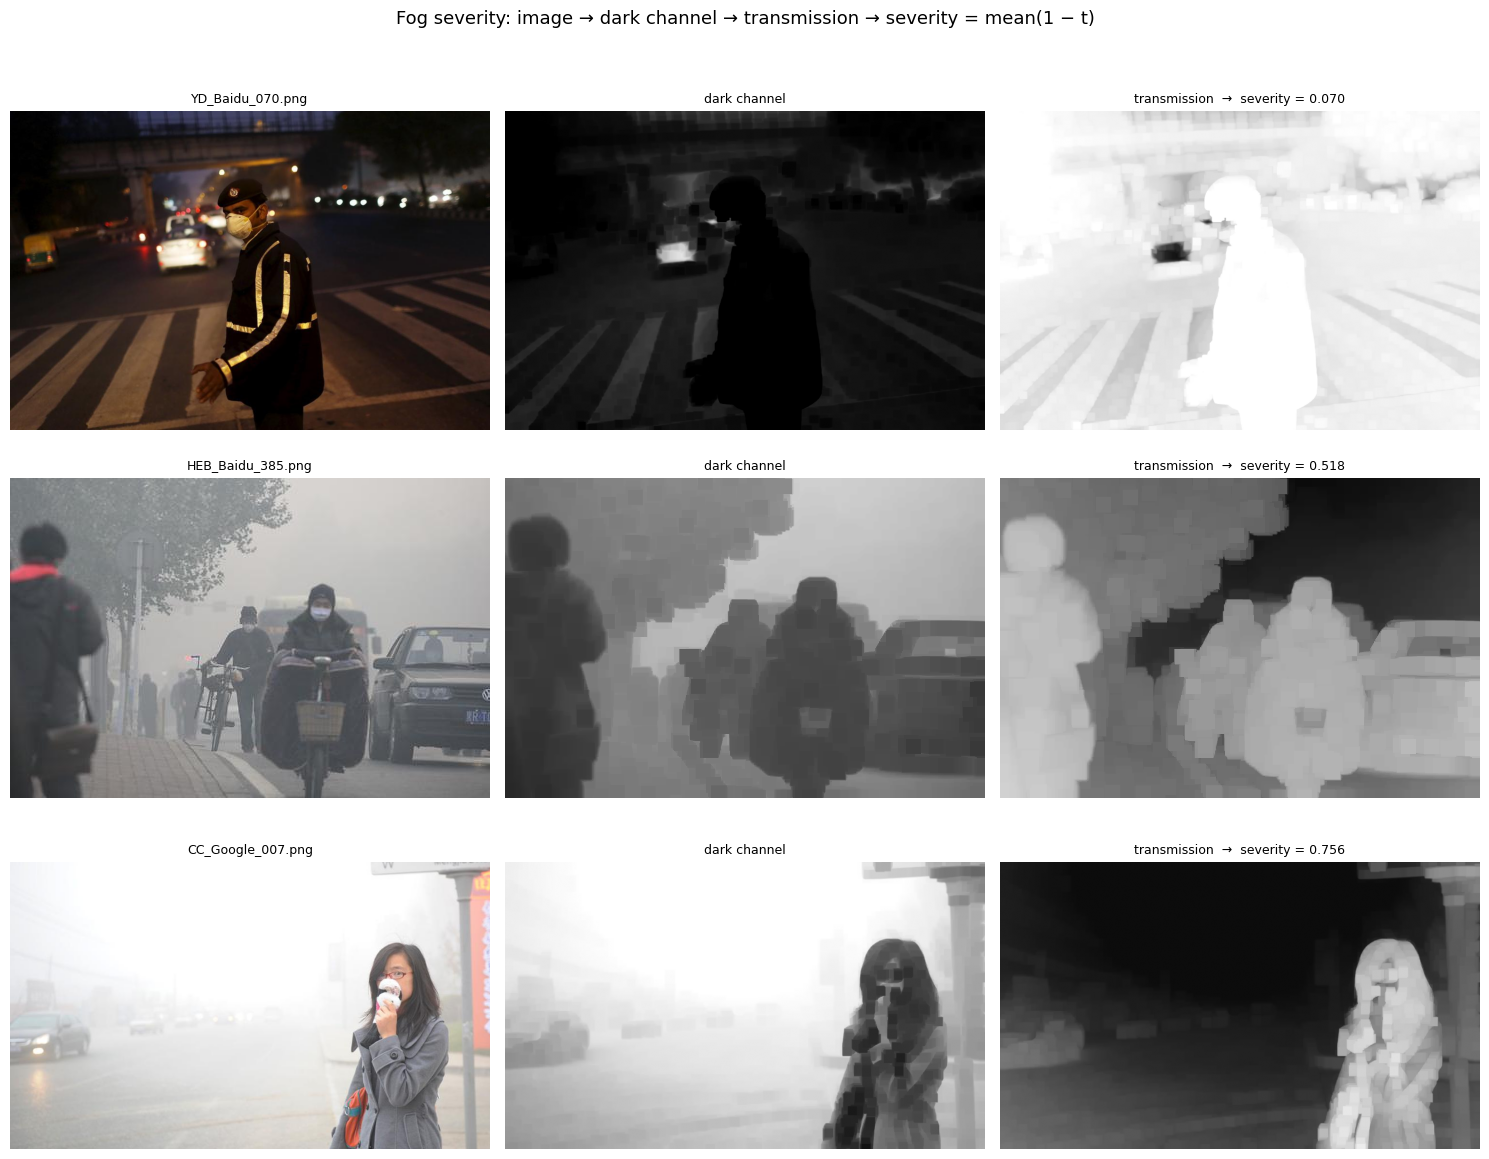

In [4]:
# Explainer: original | dark channel | transmission, with the severity value,
# for a low, a middle, and a high example.
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

features = pd.read_csv(os.path.join(TABLES_DIR, "features_RTTS.csv"))
ranked = features.sort_values("dark_channel_score").reset_index(drop=True)
example_positions = [10, len(ranked) // 2, len(ranked) - 10]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for row_index, position in enumerate(example_positions):
    row = ranked.iloc[position]
    image_bgr = cv2.imread(os.path.join(IMAGES_DIR, row["relpath"]))
    dark = feat.dark_channel_map(image_bgr)
    transmission = feat.transmission_map(image_bgr)
    severity = feat.dcp_severity_score(image_bgr)

    axes[row_index, 0].imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    axes[row_index, 0].set_title(row["filename"], fontsize=9)
    axes[row_index, 1].imshow(dark, cmap="gray", vmin=0, vmax=255)
    axes[row_index, 1].set_title("dark channel", fontsize=9)
    axes[row_index, 2].imshow(transmission, cmap="gray", vmin=0, vmax=1)
    axes[row_index, 2].set_title(f"transmission  →  severity = {severity:.3f}", fontsize=9)
    for column in range(3):
        axes[row_index, column].axis("off")

fig.suptitle("Fog severity: image → dark channel → transmission → severity = mean(1 − t)",
             fontsize=13, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.98])
figure_path = os.path.join(FIGURES_DIR, "fig_13_severity_explainer_RTTS.jpg")
plt.savefig(figure_path, dpi=100, format="jpg", bbox_inches="tight")
print("Saved:", figure_path)
plt.show()

In [5]:
# Compute severity for every RTTS image and save one value per image to Drive.
severity_path = os.path.join(TABLES_DIR, "severity_RTTS.csv")

if os.path.exists(severity_path):
    severity_table = pd.read_csv(severity_path)
    print(f"Already computed: {len(severity_table)} rows")
else:
    records = []
    for count, (_, row) in enumerate(features.iterrows(), start=1):
        image_bgr = cv2.imread(os.path.join(IMAGES_DIR, row["relpath"]))
        if image_bgr is None:
            continue
        records.append({
            "filename": row["filename"],
            "stem": os.path.splitext(row["filename"])[0],
            "severity": feat.dcp_severity_score(image_bgr),
        })
        if count % 500 == 0:
            print(f"  {count} / {len(features)}")
    severity_table = pd.DataFrame(records)
    severity_table.to_csv(severity_path, index=False)
    print(f"Saved {len(severity_table)} rows to {severity_path}")

print(severity_table["severity"].describe().round(3).to_string())

  500 / 4322
  1000 / 4322
  1500 / 4322
  2000 / 4322
  2500 / 4322
  3000 / 4322
  3500 / 4322
  4000 / 4322
Saved 4322 rows to /content/drive/MyDrive/perception-difficulty-dve/results/tables/severity_RTTS.csv
count    4322.000
mean        0.521
std         0.144
min         0.010
25%         0.425
50%         0.528
75%         0.622
max         0.868


Saved: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_14_severity_distribution_RTTS.jpg


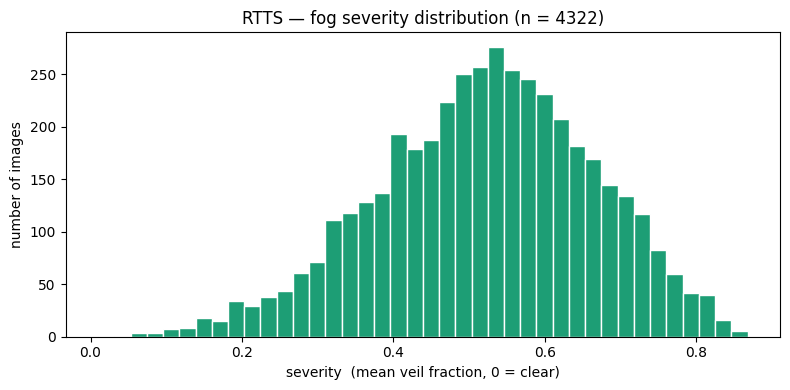

In [6]:
# Distribution of severity across RTTS.
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(severity_table["severity"], bins=40, color="#1D9E75", edgecolor="white")
ax.set_xlabel("severity  (mean veil fraction, 0 = clear)")
ax.set_ylabel("number of images")
ax.set_title(f"RTTS — fog severity distribution (n = {len(severity_table)})")
plt.tight_layout()
figure_path = os.path.join(FIGURES_DIR, "fig_14_severity_distribution_RTTS.jpg")
plt.savefig(figure_path, dpi=110, format="jpg", bbox_inches="tight")
print("Saved:", figure_path)
plt.show()

## Output

severity_RTTS.csv — one severity value per image (n = 4,322), the measurement used
by all subsequent notebooks. References: He, Sun & Tang (2009); Lee et al. (2016);
Guo, Wang & Li (2022).